# Crop Yield Dataset — Data Preprocessing

**Objective:** Clean and preprocess the crop yield dataset so it is ready for exploratory data analysis and modeling.


1. Load and explore the dataset
2. Handle missing values
3. Remove duplicate records
4. Fix inconsistent text/categorical entries
5. Fix data types
6. Detect and handle outliers
7. Encode categorical variables
8. Scale numerical features
9. Save the final cleaned dataset


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style('whitegrid')
%matplotlib inline


## 2. Load the Dataset

In [ ]:
df = pd.read_csv('crop_yield_dataset.csv')
df.head()


,District,Year,Crop,Season,Area_Cultivated_Hectares,Average_Temperature_C,Total_Rainfall_mm,Humidity_Percent,Soil_Type,Soil_pH,Nitrogen_N_kg_per_ha,Phosphorus_P_kg_per_ha,Potassium_K_kg_per_ha,Irrigation_Availability,Yield_kg_per_ha,Total_Yield_kg
0,Aurangabad,2023,Bajra,RABI,8.01,28.3,540.7,72.9,Black,6.71,106.09,61.01,29.72,Partially Irrigated,1789.90,14338.90
1,AKOLA,2018,Sunflower,KHARIF,43.31,24.8,577.9,45.7,Sandy,6.79,72.95,50.9,59.57,Irrigated,1782.90,77211.00
2,amravati,2015,Cotton,Zaid,3.32,17.3,1041.7,44.3,Red,6.67,101.64,30.87,43.34,Partially Irrigated,1611.74,5347.81
3,Amravati,2020,sugarcane,zaid,21.01,28.6,1185.0,89.3,Sandy,7.36,216.15,111.79,114.61,PARTIALLY IRRIGATED,64647.00,1358295.43
4,amravati,2018,Wheat,Kharif,24.44,22.6,538.6,64.0,Loamy,6.80,119.29,87.66,38.14,Partially Irrigated,3830.25,93629.41


In [ ]:
print("Shape of dataset:", df.shape)


Shape of dataset: (5060, 16)


## 3. Initial Exploration

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5060 entries, 0 to 5059
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   District                  5060 non-null   str    
 1   Year                      5060 non-null   int64  
 2   Crop                      5060 non-null   str    
 3   Season                    5060 non-null   str    
 4   Area_Cultivated_Hectares  5060 non-null   float64
 5   Average_Temperature_C     4833 non-null   float64
 6   Total_Rainfall_mm         4870 non-null   float64
 7   Humidity_Percent          4884 non-null   float64
 8   Soil_Type                 4903 non-null   str    
 9   Soil_pH                   4905 non-null   float64
 10  Nitrogen_N_kg_per_ha      4737 non-null   float64
 11  Phosphorus_P_kg_per_ha    5031 non-null   str    
 12  Potassium_K_kg_per_ha     5031 non-null   str    
 13  Irrigation_Availability   4765 non-null   str    
 14  Yield_kg_per_ha    

In [ ]:
df.describe(include='all')


,District,Year,Crop,Season,Area_Cultivated_Hectares,Average_Temperature_C,Total_Rainfall_mm,Humidity_Percent,Soil_Type,Soil_pH,Nitrogen_N_kg_per_ha,Phosphorus_P_kg_per_ha,Potassium_K_kg_per_ha,Irrigation_Availability,Yield_kg_per_ha,Total_Yield_kg
count,5060,5060.000000,5060,5060,5060.000000,4833.000000,4870.000000,4884.000000,4903,4905.000000,4737.000000,5031,5031,4765,5060.000000,5.060000e+03
unique,75,NaN,50,15,NaN,NaN,NaN,NaN,30,NaN,NaN,3537,3632,15,NaN,NaN
top,Kolhapur,NaN,Jowar,Zaid,NaN,NaN,NaN,NaN,Red,NaN,NaN,unknown,unknown,Irrigated,NaN,NaN
freq,203,NaN,310,968,NaN,NaN,NaN,NaN,470,NaN,NaN,30,33,948,NaN,NaN
mean,NaN,2019.525296,NaN,NaN,25.665954,26.885914,809.406391,64.628358,NaN,6.725270,85.827678,NaN,NaN,NaN,7950.225037,2.038296e+05
std,NaN,2.877816,NaN,NaN,15.174434,8.562136,563.664837,14.249301,NaN,0.578936,54.479037,NaN,NaN,NaN,18171.923083,5.422052e+05
min,NaN,2015.000000,NaN,NaN,-45.970000,-26.400000,-1327.000000,40.000000,NaN,4.610000,3.590000,NaN,NaN,NaN,-4272.790000,1.162830e+03
25%,NaN,2017.000000,NaN,NaN,13.477500,23.500000,480.300000,52.400000,NaN,6.340000,44.430000,NaN,NaN,NaN,1609.282500,2.887573e+04
50%,NaN,2020.000000,NaN,NaN,25.675000,26.900000,610.700000,64.600000,NaN,6.730000,76.200000,NaN,NaN,NaN,2170.645000,5.619606e+04
75%,NaN,2022.000000,NaN,NaN,37.730000,30.100000,852.175000,76.900000,NaN,7.110000,110.670000,NaN,NaN,NaN,3350.867500,9.812549e+04


In [ ]:
df.columns


Index(['District', 'Year', 'Crop', 'Season', 'Area_Cultivated_Hectares',
       'Average_Temperature_C', 'Total_Rainfall_mm', 'Humidity_Percent',
       'Soil_Type', 'Soil_pH', 'Nitrogen_N_kg_per_ha',
       'Phosphorus_P_kg_per_ha', 'Potassium_K_kg_per_ha',
       'Irrigation_Availability', 'Yield_kg_per_ha', 'Total_Yield_kg'],
      dtype='str')

## 4. Handling Missing Values

First, let's check how many missing values each column has.

In [ ]:
df.isnull().sum()


District                      0
Year                          0
Crop                          0
Season                        0
Area_Cultivated_Hectares      0
Average_Temperature_C       227
Total_Rainfall_mm           190
Humidity_Percent            176
Soil_Type                   157
Soil_pH                     155
Nitrogen_N_kg_per_ha        323
Phosphorus_P_kg_per_ha       29
Potassium_K_kg_per_ha        29
Irrigation_Availability     295
Yield_kg_per_ha               0
Total_Yield_kg                0
dtype: int64

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent > 0].sort_values(ascending=False)


Nitrogen_N_kg_per_ha       6.383399
Irrigation_Availability    5.830040
Average_Temperature_C      4.486166
Total_Rainfall_mm          3.754941
Humidity_Percent           3.478261
Soil_Type                  3.102767
Soil_pH                    3.063241
Phosphorus_P_kg_per_ha     0.573123
Potassium_K_kg_per_ha      0.573123
dtype: float64

Some numeric columns also have missing values hidden as placeholder strings like `'NA'`, `'unknown'`, `'-'`, `'?'`. Let's convert those to proper `NaN` values.

In [ ]:
placeholder_values = ['NA', 'na', 'unknown', 'Unknown', '-', '?', '']
df.replace(placeholder_values, np.nan, inplace=True)


,District,Year,Crop,Season,Area_Cultivated_Hectares,Average_Temperature_C,Total_Rainfall_mm,Humidity_Percent,Soil_Type,Soil_pH,Nitrogen_N_kg_per_ha,Phosphorus_P_kg_per_ha,Potassium_K_kg_per_ha,Irrigation_Availability,Yield_kg_per_ha,Total_Yield_kg
0,Aurangabad,2023,Bajra,RABI,8.01,28.3,540.7,72.9,Black,6.71,106.09,61.01,29.72,Partially Irrigated,1789.90,14338.90
1,AKOLA,2018,Sunflower,KHARIF,43.31,24.8,577.9,45.7,Sandy,6.79,72.95,50.9,59.57,Irrigated,1782.90,77211.00
2,amravati,2015,Cotton,Zaid,3.32,17.3,1041.7,44.3,Red,6.67,101.64,30.87,43.34,Partially Irrigated,1611.74,5347.81
3,Amravati,2020,sugarcane,zaid,21.01,28.6,1185.0,89.3,Sandy,7.36,216.15,111.79,114.61,PARTIALLY IRRIGATED,64647.00,1358295.43
4,amravati,2018,Wheat,Kharif,24.44,22.6,538.6,64.0,Loamy,6.80,119.29,87.66,38.14,Partially Irrigated,3830.25,93629.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,Pune,2023,Rice,rabi,48.78,22.7,1208.3,43.9,Laterite,6.03,122.76,68.73,50.55,Rainfed,3910.12,190750.26
5056,AMRAVATI,2020,rice,Kharif,6.80,32.1,1385.9,59.2,Laterite,7.19,NaN,42.67,33.21,Partially Irrigated_,3775.27,25666.06
5057,Akola,2016,Jowar,Kharif,32.29,31.1,470.6,62.6,Sandy,5.91,59.39,39.86,22.85,Irrigated,2342.75,75651.98
5058,Kolhapur,2017,Sunflower,ZAID,34.13,25.8,221.8,73.8,Sandy,7.01,84.84,57.96,48.21,Rainfed,1085.83,37055.88


In [ ]:
# Make sure numeric columns that got corrupted by placeholder strings are actually numeric
numeric_cols = ['Area_Cultivated_Hectares', 'Average_Temperature_C', 'Total_Rainfall_mm',
                 'Humidity_Percent', 'Soil_pH', 'Nitrogen_N_kg_per_ha',
                 'Phosphorus_P_kg_per_ha', 'Potassium_K_kg_per_ha',
                 'Yield_kg_per_ha', 'Total_Yield_kg']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols].dtypes


Area_Cultivated_Hectares    float64
Average_Temperature_C       float64
Total_Rainfall_mm           float64
Humidity_Percent            float64
Soil_pH                     float64
Nitrogen_N_kg_per_ha        float64
Phosphorus_P_kg_per_ha      float64
Potassium_K_kg_per_ha       float64
Yield_kg_per_ha             float64
Total_Yield_kg              float64
dtype: object

In [ ]:
df.isnull().sum()


District                      0
Year                          0
Crop                          0
Season                        0
Area_Cultivated_Hectares      0
Average_Temperature_C       227
Total_Rainfall_mm           190
Humidity_Percent            176
Soil_Type                   157
Soil_pH                     155
Nitrogen_N_kg_per_ha        323
Phosphorus_P_kg_per_ha      102
Potassium_K_kg_per_ha       101
Irrigation_Availability     295
Yield_kg_per_ha               0
Total_Yield_kg                0
dtype: int64

Now let's fill in the missing values:
- Numeric columns → fill with the **median** (robust to outliers)
- Categorical columns → fill with the **mode** (most frequent value)

In [ ]:
categorical_cols = ['District', 'Crop', 'Season', 'Soil_Type', 'Irrigation_Availability']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()


District                    0
Year                        0
Crop                        0
Season                      0
Area_Cultivated_Hectares    0
Average_Temperature_C       0
Total_Rainfall_mm           0
Humidity_Percent            0
Soil_Type                   0
Soil_pH                     0
Nitrogen_N_kg_per_ha        0
Phosphorus_P_kg_per_ha      0
Potassium_K_kg_per_ha       0
Irrigation_Availability     0
Yield_kg_per_ha             0
Total_Yield_kg              0
dtype: int64

## 5. Removing Duplicate Records

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 60


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (5000, 16)


## 6. Cleaning Inconsistent Categorical / Text Data

Categorical columns often have inconsistent casing, extra whitespace, or stray characters. Let's standardize them.

In [ ]:
for col in categorical_cols:
    print(col, "->", df[col].unique()[:15])


District -> <StringArray>
[  'Aurangabad',        'AKOLA',     'amravati',     'Amravati',
       'Satara',       'Wardha',     'Yavatmal',  '  Solapur  ',
        'Dhule', '  Amravati  ',     'yavatmal',     'YAVATMAL',
   'AHMEDNAGAR',       'Nagpur',     'Kolhapur']
Length: 15, dtype: str
Crop -> <StringArray>
[    '  Bajra  ', '  Sunflower  ',        'Cotton',     'sugarcane',
     '  Wheat  ',       'SOYBEAN',     'Sunflower',         'Jowar',
         'Wheat',       'Soybean',         'WHEAT',          'rice',
         'BAJRA',          'Rice',        'Maize_']
Length: 15, dtype: str
Season -> <StringArray>
[      'RABI',     'KHARIF',       'Zaid',       'zaid',     'Kharif',
   '  Rabi  ',       'Rabi',      'Zaid_',       'ZAID',   '  Zaid  ',
      'Rabi_',     'kharif',       'rabi',    'Kharif_', '  Kharif  ']
Length: 15, dtype: str
Soil_Type -> <StringArray>
[       'Black',    '  Sandy  ',          'Red',        'Loamy',
     'Laterite',        'SANDY',       'clayey',   

In [ ]:
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()      # remove leading/trailing spaces
    df[col] = df[col].str.replace('_', '', regex=False)  # remove stray underscores
    df[col] = df[col].str.title()                  # standardize casing

for col in categorical_cols:
    print(col, "->", sorted(df[col].unique()))


District -> ['Ahmednagar', 'Akola', 'Amravati', 'Aurangabad', 'Dhule', 'Jalgaon', 'Kolhapur', 'Nagpur', 'Nashik', 'Pune', 'Sangli', 'Satara', 'Solapur', 'Wardha', 'Yavatmal']
Crop -> ['Bajra', 'Cotton', 'Groundnut', 'Jowar', 'Maize', 'Rice', 'Soybean', 'Sugarcane', 'Sunflower', 'Wheat']
Season -> ['Kharif', 'Rabi', 'Zaid']
Soil_Type -> ['Black', 'Clayey', 'Laterite', 'Loamy', 'Red', 'Sandy']
Irrigation_Availability -> ['Irrigated', 'Partially Irrigated', 'Rainfed']


## 7. Fixing Data Types

The `Year` column should be an integer, but got corrupted with extra whitespace/string formatting during data entry.

In [ ]:
df['Year'] = df['Year'].astype(str).str.strip()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')
df['Year'].unique()


<IntegerArray>
[2023, 2018, 2015, 2020, 2017, 2024, 2022, 2019, 2021, 2016]
Length: 10, dtype: Int64

In [ ]:
df.dtypes


District                        str
Year                          Int64
Crop                            str
Season                          str
Area_Cultivated_Hectares    float64
Average_Temperature_C       float64
Total_Rainfall_mm           float64
Humidity_Percent            float64
Soil_Type                       str
Soil_pH                     float64
Nitrogen_N_kg_per_ha        float64
Phosphorus_P_kg_per_ha      float64
Potassium_K_kg_per_ha       float64
Irrigation_Availability         str
Yield_kg_per_ha             float64
Total_Yield_kg              float64
dtype: object

## 8. Detecting and Handling Outliers

Some numeric columns (like rainfall and area) contain impossible values, such as negative numbers or extreme spikes. Let's inspect and fix these using the IQR method.

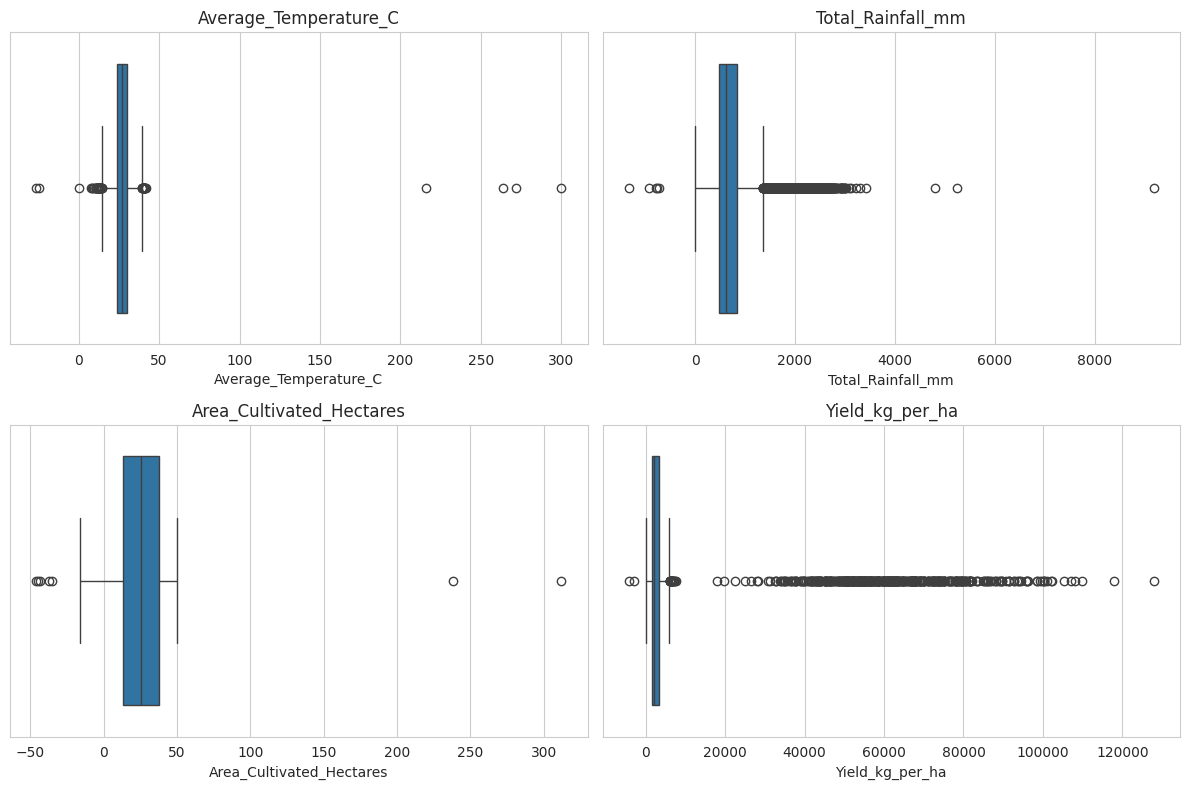

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
outlier_check_cols = ['Average_Temperature_C', 'Total_Rainfall_mm', 'Area_Cultivated_Hectares', 'Yield_kg_per_ha']

for ax, col in zip(axes.flatten(), outlier_check_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [ ]:
# Physically impossible negative values -> treat as missing, then fill with median
for col in ['Total_Rainfall_mm', 'Area_Cultivated_Hectares']:
    df.loc[df[col] < 0, col] = np.nan
    df[col] = df[col].fillna(df[col].median())


In [ ]:
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    return data

for col in outlier_check_cols:
    df = cap_outliers_iqr(df, col)


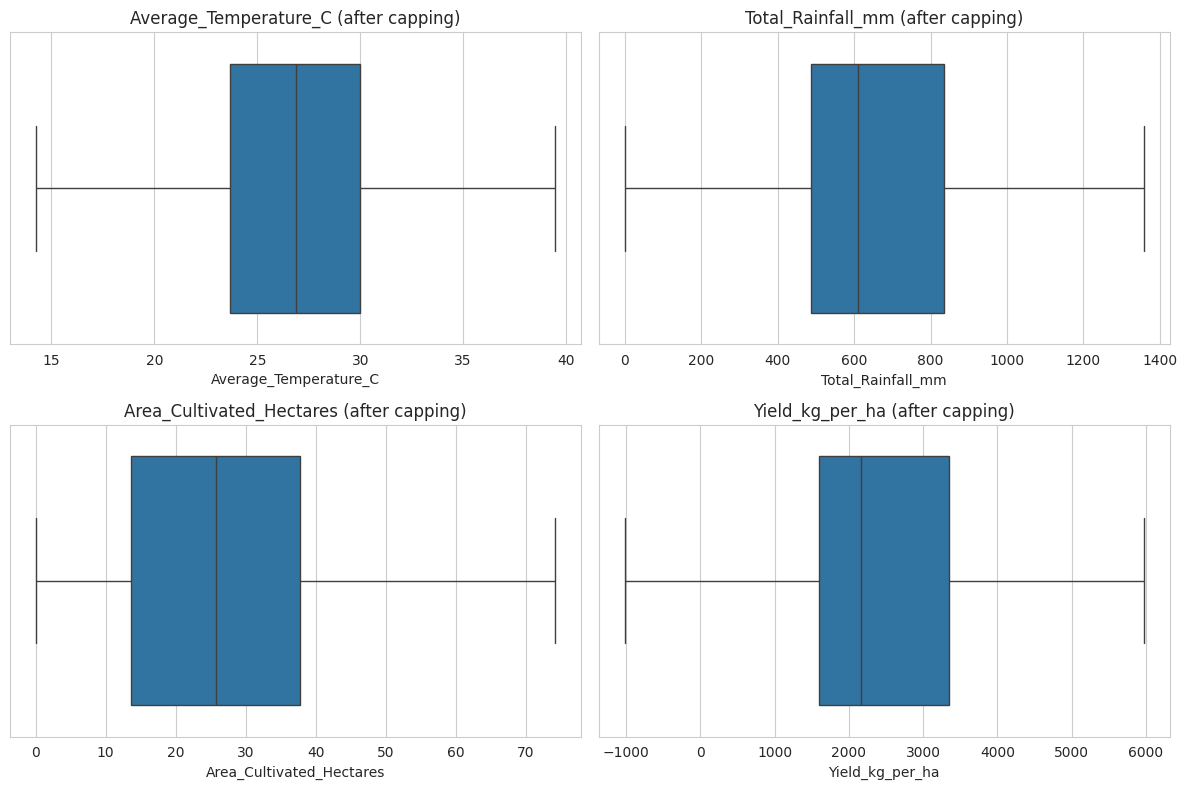

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), outlier_check_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col + " (after capping)")

plt.tight_layout()
plt.show()


## 9. Encoding Categorical Variables

Machine learning models need numeric input, so let's encode the categorical columns using Label Encoding.

In [ ]:
label_encoders = {}

df_encoded = df.copy()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded[categorical_cols].head()


,District,Crop,Season,Soil_Type,Irrigation_Availability
0,3,0,1,0,1
1,1,8,0,5,0
2,2,1,2,4,1
3,2,7,2,5,1
4,2,9,0,3,1


## 10. Feature Scaling

Let's scale the numeric features so they are on a comparable range, which helps many ML algorithms converge better.

In [ ]:
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_encoded[numeric_cols].describe()


,Area_Cultivated_Hectares,Average_Temperature_C,Total_Rainfall_mm,Humidity_Percent,Soil_pH,Nitrogen_N_kg_per_ha,Phosphorus_P_kg_per_ha,Potassium_K_kg_per_ha,Yield_kg_per_ha,Total_Yield_kg
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000
mean,-8.313350e-17,-3.261391e-16,-1.726619e-16,4.924061e-16,6.124878e-16,-1.193712e-16,-3.410605e-16,1.492140e-17,-8.810730e-17,0.000000
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100
min,-1.810806e+00,-2.574020e+00,-2.171282e+00,-1.762057e+00,-3.709808e+00,-1.546172e+00,-2.584929e+00,-2.086737e+00,-2.499851e+00,-0.374868
25%,-8.569682e-01,-6.295730e-01,-6.968629e-01,-8.403241e-01,-6.577125e-01,-7.253385e-01,-6.746115e-01,-6.876522e-01,-7.328311e-01,-0.323984
50%,2.921518e-03,2.886424e-02,-3.187447e-01,-4.334286e-03,8.837044e-03,-1.721710e-01,-1.393912e-01,-1.698329e-01,-3.512483e-01,-0.273841
75%,8.534665e-01,6.667253e-01,3.610791e-01,8.459460e-01,6.403051e-01,4.263645e-01,5.209820e-01,4.623483e-01,4.451821e-01,-0.196680
max,3.419118e+00,2.611173e+00,1.947992e+00,1.810550e+00,3.990594e+00,5.545991e+00,4.440691e+00,5.685820e+00,2.212202e+00,8.962091


## 11. Final Checks

In [ ]:
print("Final shape:", df_encoded.shape)
df_encoded.isnull().sum().sum()


Final shape: (5000, 16)


np.int64(0)

In [ ]:
df_encoded.head()


,District,Year,Crop,Season,Area_Cultivated_Hectares,Average_Temperature_C,Total_Rainfall_mm,Humidity_Percent,Soil_Type,Soil_pH,Nitrogen_N_kg_per_ha,Phosphorus_P_kg_per_ha,Potassium_K_kg_per_ha,Irrigation_Availability,Yield_kg_per_ha,Total_Yield_kg
0,3,2023,0,1,-1.247507,0.316931,-0.531213,0.588718,0,-0.026245,0.393438,0.389005,-0.882543,1,-0.607378,-0.350698
1,1,2018,8,0,1.242065,-0.403235,-0.418301,-1.354779,5,0.114082,-0.233671,-0.103807,0.326917,0,-0.612098,-0.235368
2,2,2015,1,2,-1.578274,-1.946447,0.989455,-1.454812,4,-0.096408,0.309231,-1.080170,-0.330689,1,-0.727511,-0.367191
3,2,2020,7,2,-0.330667,0.378659,1.424409,1.760533,5,1.113906,2.476107,2.864277,2.557024,1,2.212202,2.114600
4,2,2018,9,0,-0.088762,-0.855911,-0.537587,-0.047206,3,0.131622,0.643222,1.688060,-0.541382,1,0.768430,-0.205251


## 12. Save the Cleaned Dataset

In [ ]:
df.to_csv('crop_yield_dataset_cleaned.csv', index=False)
df_encoded.to_csv('crop_yield_dataset_preprocessed.csv', index=False)

print("Cleaned dataset saved as 'crop_yield_dataset_cleaned.csv'")
print("Preprocessed (encoded + scaled) dataset saved as 'crop_yield_dataset_preprocessed.csv'")


Cleaned dataset saved as 'crop_yield_dataset_cleaned.csv'
Preprocessed (encoded + scaled) dataset saved as 'crop_yield_dataset_preprocessed.csv'
